In [2]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import random
import importlib
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import sys
import os

# Add the 'code' folder directly to Python's search path
sys.path.append(os.path.join(os.getcwd(), 'src'))
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from scipy.linalg import sqrtm


#import the synthetic data generation functions
import src.synthetic_data as syn_data
importlib.reload(syn_data)

#import the Wasserstein k-means clustering functions
import src.wasserstein as ws
importlib.reload(ws)

#import performance metrics functions for clustering evaluation 
import src.metrics as mt 
importlib.reload(mt)


#import trading alogrithms function for empirical performance 
import src.trading as tr
importlib.reload(tr)

import src.ledoit_wolf_sharpe_test as lw
importlib.reload(lw)

# Access to refinitiv data 
import refinitiv.data as rd

import src.equities_refinitiv as eq_ref
import src.macro_data as macro

# import FREDAPI 
from fredapi import Fred

#yahoo finance 
import yfinance as yf


import src.equity_loader as equity_loader

# (1) Tuning Hysteresis (Entry/Exit Threshold)

## (1.1) Tuning for American Markets 

In [3]:
start_date = '2006-01-01'
end_date = '2020-01-01'
interval = '1d'

In [4]:
df_america = equity_loader.get_close_prices(start_date=start_date, end_date=end_date, regions=['america'], interval=interval)

df_america.dropna(inplace=True)


In [9]:
h2 = 1
h1 = 3
window_size = 20
N_S = 40
signal_type = "hysteresis"
_lookback = 10
S = df_america
L = 100
_initial_capital = 100
grad_weight = 0.5
_use_gradient = False
_live_plot = False

entry_threshold_list = [0.28, 0.29, 0.3]
hold_threshold_list  = [0.29, 0.3, 0.31]

# Store Sharpe ratios in a 2D array
sharpe_matrix = pd.DataFrame(index=entry_threshold_list, columns=hold_threshold_list, dtype=float)

for entry_threshold, hold_threshold in product(entry_threshold_list, hold_threshold_list):
    if entry_threshold >= hold_threshold:
        sharpe_matrix.loc[entry_threshold, hold_threshold] = np.nan
        continue

    print(f"Running entry={entry_threshold}, hold={hold_threshold}")

    portfolio_values, _, _, _  = tr.long_strat_implied(_initial_capital, N_S, S, L, h1, h2, window_size, start_date=start_date, end_date=end_date, signal_type=signal_type, entry_threshold=entry_threshold, hold_threshold=hold_threshold, lookback=_lookback, gradient_weight=grad_weight, use_gradient=_use_gradient, live_plot=_live_plot)

    # Compute Sharpe ratio from returns (adjust if your function returns something different)
    returns = np.diff(portfolio_values) / portfolio_values[:-1]
    if returns.std() > 0:
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252 * 14)  # annualised for 14 years 
    else:
        sharpe = np.nan

    sharpe_matrix.loc[entry_threshold, hold_threshold] = sharpe



Running entry=0.28, hold=0.29
Running entry=0.28, hold=0.3
Running entry=0.28, hold=0.31
Running entry=0.29, hold=0.3
Running entry=0.29, hold=0.31
Running entry=0.3, hold=0.31


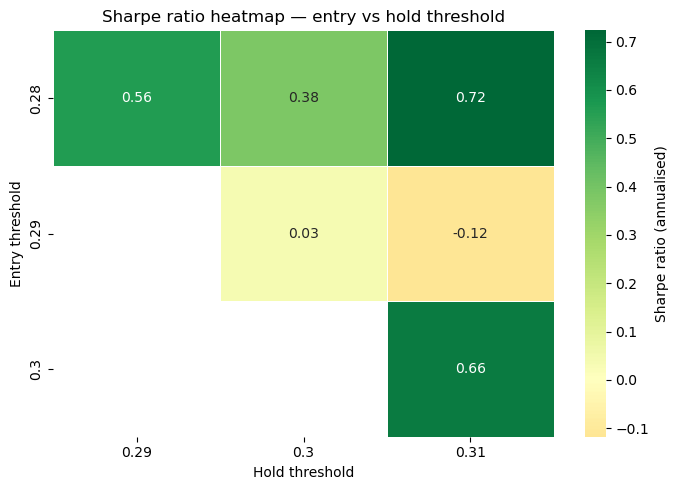

In [11]:
# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    sharpe_matrix.astype(float),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Sharpe ratio (annualised)"}
)
ax.set_title("Sharpe ratio heatmap — entry vs hold threshold")
ax.set_xlabel("Hold threshold")
ax.set_ylabel("Entry threshold")
plt.tight_layout()
plt.show()

# (2) Tuning Gradient Params for Implied Sliced Wasserstein Probability trading strategy 

# (3) Tuning Ensemble Method Signal Weighting 

In [ ]:
### Try out different weighting schemes for ensemble method to look for best performance
